# Pricing the book

A return costs **$8** to ship back and process. Coverage is priced so that each order carries a target **gross margin** — margin measured on revenue, the conventional commercial sense of the word:

> `price = (probability of return × $8) / (1 − margin)`

Because the probability is calibrated, this earns the target **by construction on every order**: per-order margin is `(p − c)/p = margin` regardless of what the claim costs. No optimiser, and no dependence on the demand curve.

A note on the two conventions, because they differ by real money. **Margin on price** divides by `(1 − m)`; **markup on cost** multiplies by `(1 + m)`. At 60% on a $7.95 claim that is $19.87 against $12.72. This notebook uses margin, the stricter of the two.

**Setup.** Prices come from the margin rule and need no demand assumption. Attach and revenue do, so the demand curve is anchored to a plausible coverage product: 35% of shoppers buy at $5.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.special import expit, logit
from src.data import INTERIM, ROOT
import matplotlib.pyplot as plt
FIGURES = ROOT / "figures"; FIGURES.mkdir(exist_ok=True)

RETURN_COST = 8.0
MARGINS = {"45%": 0.45, "60%": 0.60}
MORAL_HAZARD, ADVERSE_SELECTION = 0.10, 2.0
ANCHOR_PRICE, ANCHOR_ATTACH, PRICE_SLOPE = 5.0, 0.35, 0.15
BOOK = 100_000_000

p = pd.read_parquet(INTERIM / "predictions.parquet")
r = np.clip(p.pred.values, 1e-6, 1 - 1e-6)
r_eff = r + MORAL_HAZARD * (1 - r)
claim = r_eff * RETURN_COST
print(f"{len(p):,} orders | mean expected claim ${claim.mean():.2f}")
for label, m in MARGINS.items():
    print(f"  {label} margin -> divide by {1-m:.2f};  a $7.95 claim prices at ${7.95/(1-m):.2f}")

113,966 orders | mean expected claim $5.35
  45% margin -> divide by 0.55;  a $7.95 claim prices at $14.45
  60% margin -> divide by 0.40;  a $7.95 claim prices at $19.88


**Demand.** Used only for attach and revenue, and for solving the flat comparison price. It never sets a risk-based price.

In [2]:
r_mean = r.mean()
INTERCEPT = brentq(
    lambda a: expit(a - PRICE_SLOPE * ANCHOR_PRICE + ADVERSE_SELECTION * (r - r_mean)).mean() - ANCHOR_ATTACH,
    -40, 40)

def outcome(price):
    price = np.broadcast_to(np.asarray(price, dtype=float), r.shape)
    t = expit(INTERCEPT - PRICE_SLOPE * price + ADVERSE_SELECTION * (r - r_mean))
    revenue = float(np.mean(t * price))
    claims = float(np.mean(t * claim))
    profit = revenue - claims
    return {"attach": float(t.mean()), "revenue": revenue, "claims": claims, "profit": profit,
            "margin": profit / revenue if revenue > 0 else np.nan}

## The price card

**The price card.** Each order's price is its expected claim divided by `(1 − margin)`. The `margin_45` column is the check that matters: it reads 0.45 for every decile. That is algebra, not an optimisation result — per-order margin is `(p − c)/p = margin` regardless of `c`, so the target holds identically across the whole book.

In [3]:
book = pd.DataFrame({"risk": r, "claim": claim})
book["decile"] = pd.qcut(book.risk, 10, labels=False, duplicates="drop")
for label, m in MARGINS.items():
    book[f"price_{label}"] = book.claim / (1 - m)

card = book.groupby("decile").agg(
    orders=("risk", "size"), return_prob=("risk", "mean"), expected_claim=("claim", "mean"),
    price_45=("price_45%", "mean"), price_60=("price_60%", "mean"))
card["ev_45"] = card.price_45 - card.expected_claim
card["ev_60"] = card.price_60 - card.expected_claim
card["margin_45"] = card.ev_45 / card.price_45
card.round(2)

,orders,return_prob,expected_claim,price_45,price_60,ev_45,ev_60,margin_45
decile,,,,,,,,
0,11397,0.15,1.89,3.44,4.73,1.55,2.84,0.45
1,11397,0.28,2.80,5.09,6.99,2.29,4.20,0.45
2,11396,0.38,3.52,6.40,8.80,2.88,5.28,0.45
3,11397,0.48,4.27,7.76,10.68,3.49,6.41,0.45
4,11396,0.60,5.09,9.25,12.72,4.16,7.63,0.45
5,11397,0.72,5.97,10.86,14.93,4.89,8.96,0.45
6,11396,0.83,6.79,12.35,16.98,5.56,10.19,0.45
7,11397,0.92,7.43,13.51,18.57,6.08,11.14,0.45
8,11396,0.97,7.80,14.18,19.50,6.38,11.70,0.45


Every decile shows the same 45% in `margin_45` — that is the by-construction property, not an optimisation result. The safest decile pays $3.44 for coverage costing $1.89; the riskiest pays $14.45 for coverage costing $7.95.

## The flat price that earns the same margin

**A fair opponent.** Rather than assuming what a platform charges today, this solves for the single flat price that earns the *same* margin across the book. Comparing the card against an arbitrarily chosen flat rate would rig the test; comparing against the best available flat rate does not.

In [4]:
def flat_at_margin(target):
    """The single price whose aggregate margin equals the target."""
    return brentq(lambda price: outcome(price)["margin"] - target, 0.51, 400.0)

flat = {label: flat_at_margin(m) for label, m in MARGINS.items()}
for label, price in flat.items():
    o = outcome(price)
    print(f"{label} margin -> one flat price of ${price:.2f}  (attach {o['attach']:.1%}, margin {o['margin']:.1%})")

45% margin -> one flat price of $11.34  (attach 18.0%, margin 45.0%)
60% margin -> one flat price of $15.77  (attach 10.3%, margin 60.0%)


## Flat against the card

**Flat against the card at identical margin.** Because both policies earn the same margin by construction, the comparison reduces to volume and composition: who attaches, and what the resulting book costs to service. Everything is scaled to the order count that makes the flat policy's revenue $100M.

In [5]:
rows = []
for label, m in MARGINS.items():
    f = outcome(flat[label])
    k = outcome(book[f"price_{label}"].values)
    orders = BOOK / f["revenue"]
    for name, o in [(f"flat ${flat[label]:.2f}", f), (f"price card ({label} margin)", k)]:
        rows.append({"target": label, "policy": name, "attach": o["attach"], "margin": o["margin"],
                     "revenue_100M": o["revenue"] * orders, "contribution": o["profit"] * orders})
compare = pd.DataFrame(rows)
compare[["revenue_100M", "contribution"]] = compare[["revenue_100M", "contribution"]].round(0)
compare.round(4)

,target,policy,attach,margin,revenue_100M,contribution
0,45%,flat $11.34,0.1796,0.45,100000000.0,45000000.0
1,45%,price card (45% margin),0.2010,0.45,96288728.0,43329928.0
2,60%,flat $15.77,0.1033,0.60,100000000.0,60000000.0
3,60%,price card (60% margin),0.1287,0.60,98415216.0,59049130.0


## Who actually buys under each policy

A flat rate and a price card do not just differ in price, they differ in **who accepts**. Under one flat price the high-risk shopper is getting a bargain and the low-risk shopper is being overcharged, so the book fills up with exactly the orders most likely to claim — textbook adverse selection. Under the card the high-risk shopper is quoted $14.45 and may simply decline and pay their own return shipping, while the low-risk shopper is quoted $3.44 and takes it.

This cell measures that composition shift directly: attach rate by risk decile under each policy, and the resulting risk profile of the policies actually sold.

In [6]:
def attach_by_decile(price):
    price = np.broadcast_to(np.asarray(price, dtype=float), r.shape)
    t = expit(INTERCEPT - PRICE_SLOPE * price + ADVERSE_SELECTION * (r - r_mean))
    d = pd.DataFrame({"decile": book.decile, "risk": r, "t": t, "claim": claim,
                      "price": price})
    g = d.groupby("decile").apply(lambda x: pd.Series({
        "attach": x.t.mean(),
        "policies_share": x.t.sum(),
        "mean_price": float(np.average(x.price, weights=x.t)),
    }))
    g["policies_share"] = g.policies_share / g.policies_share.sum()
    return g, d

TARGET = "45%"
flat_g, flat_d = attach_by_decile(flat[TARGET])
card_g, card_d = attach_by_decile(book[f"price_{TARGET}"].values)

comp = pd.DataFrame({
    "attach_flat": flat_g.attach, "attach_card": card_g.attach,
    "share_flat": flat_g.policies_share, "share_card": card_g.policies_share,
    "price_card": card_g.mean_price})
comp.round(4)

,attach_flat,attach_card,share_flat,share_card,price_card
decile,,,,,
0,0.0705,0.1982,0.0393,0.0986,3.4408
1,0.0886,0.1989,0.0494,0.0990,5.0868
2,0.1062,0.1995,0.0592,0.0993,6.4004
3,0.1277,0.2001,0.0711,0.0996,7.7648
4,0.1552,0.2007,0.0864,0.0999,9.2505
5,0.1902,0.2015,0.1059,0.1003,10.8576
6,0.2278,0.2021,0.1268,0.1006,12.3518
7,0.2602,0.2027,0.1449,0.1008,13.5064
8,0.2804,0.2030,0.1562,0.1010,14.1809


**The selection measure.** Averaging each order's true return probability *weighted by its probability of buying* gives the risk profile of the policies actually sold. Comparing that to the population mean is the cleanest single number for adverse selection: how much riskier are buyers than everyone else.

In [7]:
def risk_of_buyers(d):
    return float(np.average(d.risk, weights=d.t)), float(np.average(d.claim, weights=d.t))

fr, fc = risk_of_buyers(flat_d)
cr, cc = risk_of_buyers(card_d)
print(f"population mean return probability      {r.mean():.3f}")
print(f"mean risk among buyers, flat ${flat[TARGET]:.2f}    {fr:.3f}   (expected claim ${fc:.2f})")
print(f"mean risk among buyers, price card      {cr:.3f}   (expected claim ${cc:.2f})")
print()
print(f"flat rate selects buyers {fr - r.mean():+.3f} riskier than the population")
print(f"price card selects buyers {cr - r.mean():+.3f} riskier than the population")

population mean return probability      0.632
mean risk among buyers, flat $11.34    0.755   (expected claim $6.24)
mean risk among buyers, price card      0.634   (expected claim $5.37)

flat rate selects buyers +0.123 riskier than the population
price card selects buyers +0.002 riskier than the population


**Two panels, two series each**, so both carry legends. Left: the share of shoppers who accept at each risk level. Right: what the resulting book of sold policies is composed of. The flat rate's upward slope and the card's flat line are the whole story.

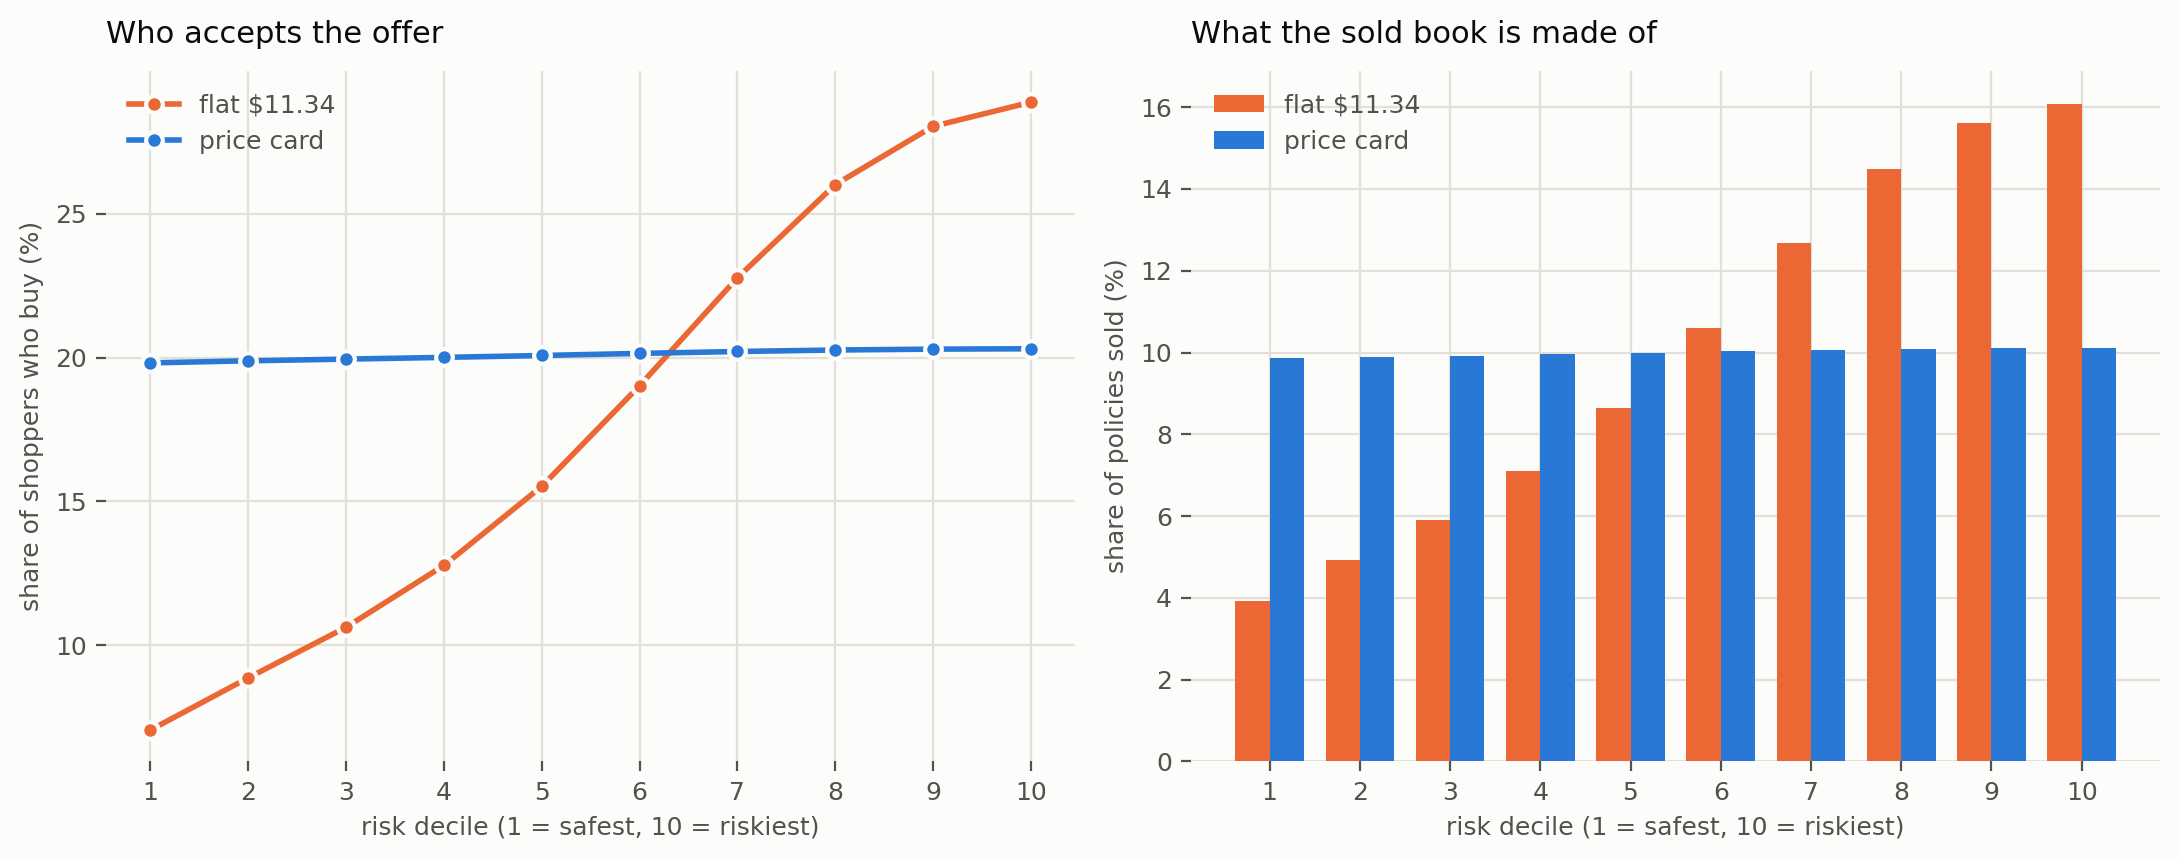

In [8]:
SURFACE, GRID, INK, MUTED, BASE = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7"
FLAT_C, CARD_C = "#eb6834", "#2a78d6"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), dpi=200)
fig.patch.set_facecolor(SURFACE)
x = np.arange(1, 11)
for a in (ax1, ax2):
    a.set_facecolor(SURFACE)
    a.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=1)
    a.set_axisbelow(True)
    for s in a.spines.values(): s.set_visible(False)
    a.tick_params(colors=MUTED, labelsize=9)
    a.set_xticks(x)

ax1.plot(x, comp.attach_flat * 100, color=FLAT_C, linewidth=2, marker="o", markersize=6,
         markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3, label=f"flat ${flat[TARGET]:.2f}")
ax1.plot(x, comp.attach_card * 100, color=CARD_C, linewidth=2, marker="o", markersize=6,
         markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=4, label="price card")
ax1.set_xlabel("risk decile (1 = safest, 10 = riskiest)", color=MUTED, fontsize=9)
ax1.set_ylabel("share of shoppers who buy (%)", color=MUTED, fontsize=9)
ax1.set_title("Who accepts the offer", color=INK, fontsize=11, pad=10, loc="left")
ax1.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=MUTED)

w = 0.38
ax2.bar(x - w/2, comp.share_flat * 100, width=w, color=FLAT_C, zorder=3, label=f"flat ${flat[TARGET]:.2f}")
ax2.bar(x + w/2, comp.share_card * 100, width=w, color=CARD_C, zorder=3, label="price card")
ax2.set_xlabel("risk decile (1 = safest, 10 = riskiest)", color=MUTED, fontsize=9)
ax2.set_ylabel("share of policies sold (%)", color=MUTED, fontsize=9)
ax2.set_title("What the sold book is made of", color=INK, fontsize=11, pad=10, loc="left")
ax2.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=MUTED)

fig.tight_layout()
fig.savefig(FIGURES / "selection_flip.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Scaling the rule to a $100M book

**Scaling the rule to other books.** A logit offset moves the base rate while preserving the model's ranking, so a synthetic book at any return rate inherits the same discriminative power. For each one, the flat price is re-solved and the decile range recomputed — note the contribution column never moves, because the margin rule earns its target on every order in every book.

In [9]:
def shift_to(target):
    d = brentq(lambda delta: expit(logit(r) + delta).mean() - target, -30, 30)
    return expit(logit(r) + d)

def scenario(rate):
    rr = shift_to(rate)
    rr_eff = rr + MORAL_HAZARD * (1 - rr)
    clm = rr_eff * RETURN_COST
    by_dec = pd.Series(clm).groupby(pd.qcut(rr, 10, labels=False, duplicates="drop")).mean()

    rm = rr.mean()
    icept = brentq(lambda a: expit(a - PRICE_SLOPE * ANCHOR_PRICE + ADVERSE_SELECTION * (rr - rm)).mean() - ANCHOR_ATTACH, -40, 40)
    def agg_margin(price):
        t = expit(icept - PRICE_SLOPE * price + ADVERSE_SELECTION * (rr - rm))
        rev = float(np.mean(t * price)); clms = float(np.mean(t * clm))
        return (rev - clms) / rev

    out = {"return_rate": rate, "mean_claim": clm.mean(),
           "flat_price_45": brentq(lambda pr: agg_margin(pr) - MARGINS["45%"], 0.51, 400.0)}
    for label, m in MARGINS.items():
        out[f"low_{label}"] = by_dec.iloc[0] / (1 - m)
        out[f"high_{label}"] = by_dec.iloc[-1] / (1 - m)
    out["contribution_100M_at_45"] = MARGINS["45%"] * BOOK
    return out

scenarios = pd.DataFrame([scenario(x) for x in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, float(r.mean())]])
print(f"baseline: a $100M book at a {MARGINS['45%']:.0%} margin returns "
      f"${MARGINS['45%'] * BOOK / 1e6:.0f}M contribution — identical at every return rate\n")
scenarios.round(2)

baseline: a $100M book at a 45% margin returns $45M contribution — identical at every return rate



,return_rate,mean_claim,flat_price_45,low_45%,high_45%,low_60%,high_60%,contribution_100M_at_45
0,0.10,1.52,3.26,1.47,8.92,2.03,12.27,45000000.0
1,0.15,1.88,4.30,1.50,10.98,2.06,15.10,45000000.0
2,0.20,2.24,5.36,1.53,12.28,2.11,16.89,45000000.0
3,0.25,2.60,6.37,1.59,13.09,2.18,17.99,45000000.0
4,0.30,2.96,7.31,1.66,13.58,2.29,18.68,45000000.0
5,0.40,3.68,8.88,1.92,14.10,2.64,19.38,45000000.0
6,0.50,4.40,10.09,2.36,14.32,3.25,19.69,45000000.0
7,0.63,5.35,11.34,3.44,14.45,4.73,19.87,45000000.0


The contribution column never moves: a 45% margin on $100M of coverage revenue is $45M whatever the book's return rate, because the rule earns its target on every order. What changes is the price range required to get there.

**Persist** the card, the flat prices, the scenarios and the demand parameters together, so the memo and README quote one source of truth rather than hand-copied numbers.

In [10]:
(INTERIM / "value.json").write_text(json.dumps({
    "return_cost": RETURN_COST, "margins": MARGINS, "book": BOOK,
    "baseline_contribution_45": MARGINS["45%"] * BOOK,
    "demand": {"anchor_price": ANCHOR_PRICE, "anchor_attach": ANCHOR_ATTACH, "slope": PRICE_SLOPE},
    "flat_prices": flat, "card": card.reset_index().to_dict(orient="records"),
    "scenarios": scenarios.to_dict(orient="records")}, indent=2, default=float))
print("saved")

saved
